Milestone 2 - Training and tuning Models for Pneumonia Detection

---



In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
pip install pydicom

In [4]:
import numpy as np
import pandas as pd
import os
import pydicom
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import seaborn as sns


from matplotlib import pyplot as plt

In [17]:
#Using a datagenerator to optimize memory usage and keep the image size at 512*512

class DicomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, data_dir, batch_size=4, img_size=512, shuffle=True, subset='training'):
        self.df = df
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.subset = subset
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        X, y = self.__data_generation(batch_df)

        return X, y

    def on_epoch_end(self):
        if self.subset == 'training':
            self.indices = np.arange(len(self.df))
            if self.shuffle:
                np.random.shuffle(self.indices)
        elif self.subset == 'validation':
            self.indices = np.arange(len(self.df))

    def __data_generation(self, batch_df):
        X = np.empty((len(batch_df), self.img_size, self.img_size, 1))
        y = np.empty((len(batch_df)), dtype=int)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            file_path = os.path.join(self.data_dir, row['patientId'] + '.dcm')
            ds = pydicom.dcmread(file_path)
            img = ds.pixel_array
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = img / 255.0  # Normalize the image

            # Expand dimensions to make it (1024, 1024, 1)
            X[i,] = np.expand_dims(img, axis=-1)

            # Assign the label
            y[i] = int(row['Target'])

        return X, y



# Loading and splitting into train, validation, and test sets
data_dir = '/content/drive/MyDrive/PGDM_course/capstone_data/stage_2_train_images'
labels_df = pd.read_csv('/content/drive/MyDrive/PGDM_course/capstone_data/stage_2_train_labels.csv')


In [18]:
from sklearn.model_selection import train_test_split


# Split into train, validation, and test sets
train_df, test_df = train_test_split(labels_df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

In [19]:
import numpy as np

# Parameters
batch_size = 4
img_size = 512
# Initialize generators for train, validation, and test sets
train_generator = DicomDataGenerator(train_df, data_dir, batch_size=batch_size, img_size=img_size, subset='training')
val_generator = DicomDataGenerator(val_df, data_dir, batch_size=batch_size, img_size=img_size, subset='validation')
test_generator = DicomDataGenerator(test_df, data_dir, batch_size=batch_size, img_size=img_size, subset='validation')

In [20]:
# Import the necessary libraries for model building

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    GlobalMaxPooling2D,
)
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [25]:
!pip install --upgrade tensorflow
!pip install --upgrade keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 803.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.7/347.7 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.15.2
    Uninstalling tensorboard-2.15.2:
      Successfully uninstalled tensorboard-2.15.2
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
  Attempting uninstall: tensorflow
    F

In [21]:
from tensorflow.keras.models import load_model
# Load the model
model = load_model("/content/drive/MyDrive/PGDM_course/capstone_data/" + "model3_finetuned.keras")

In [22]:
# Read the data from the saved numpy files to avoid running the previous cells

TEST_PATIENT_IDS = np.load("/content/drive/MyDrive/PGDM_course/capstone_data/" + "testPatientIds.npy")
TEST_IMAGES = np.load("/content/drive/MyDrive/PGDM_course/capstone_data/" + "testImages.npy")

# Define a test array
X_test = TEST_IMAGES

In [10]:
# Make predictions
predictions = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


In [33]:
from tensorflow.keras.models import load_model
# Load the model
model_cnn_base = load_model("/content/drive/MyDrive/PGDM_course/capstone_data/" + "cnn_base_model.keras")


In [34]:
# Evaluate the model on training, validation, and testing data
train_loss, train_acc = model_cnn_base.evaluate(train_generator)
val_loss, val_acc = model_cnn_base.evaluate(val_generator)
test_loss, test_acc = model_cnn_base.evaluate(test_generator)

5441/5441 ━━━━━━━━━━━━━━━━━━━━ 3316s 609ms/step - accuracy: 0.9393 - loss: 0.1571
605/605 ━━━━━━━━━━━━━━━━━━━━ 512s 848ms/step - accuracy: 0.8059 - loss: 0.5688
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 1252s 828ms/step - accuracy: 0.8184 - loss: 0.6025


In [47]:
# Creating a dataframe with evaluation metrics of each model

import pandas as pd

metrics_df = pd.DataFrame(columns=[
    'Model',
    'Training Loss', 'Training Accuracy',
    'Validation Loss', 'Validation Accuracy',
    'Testing Loss', 'Testing Accuracy'
])

print(metrics_df)

# Create a dictionary with the metrics
model_metrics = {
    'Model': "CNN Base Model",
    'Training Loss': train_loss, 'Training Accuracy': train_acc,
    'Validation Loss': val_loss, 'Validation Accuracy': val_acc,
    'Testing Loss': test_loss, 'Testing Accuracy': test_acc,

}

# Append the metrics to the DataFrame
model_metrics_df = pd.DataFrame([model_metrics])
metrics_df = pd.concat([metrics_df,model_metrics_df], ignore_index=True)

# Print the DataFrame to check the added metrics
metrics_df

Empty DataFrame
Columns: [Model, Training Loss, Training Accuracy, Validation Loss, Validation Accuracy, Testing Loss, Testing Accuracy]
Index: []


,Model,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy,Testing Loss,Testing Accuracy
0,CNN Base Model,0.395239,0.815274,0.43256,0.800331,0.419572,0.80483


In [48]:
metrics_df.to_csv('/content/drive/MyDrive/PGDM_course/capstone_data/accuracy_metrics.csv', index=False)

In [36]:
from tensorflow.keras.models import load_model
# Load the model
model_vgg = load_model("/content/drive/MyDrive/PGDM_course/capstone_data/" + "VGG16_model.keras")

In [37]:
# Evaluate the model on training, validation, and testing data
train_loss, train_acc = model_vgg.evaluate(train_generator)
val_loss, val_acc = model_vgg.evaluate(val_generator)
test_loss, test_acc = model_vgg.evaluate(test_generator)

5441/5441 ━━━━━━━━━━━━━━━━━━━━ 202s 37ms/step - accuracy: 0.8149 - loss: 0.3955
605/605 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.7909 - loss: 0.4585
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.8116 - loss: 0.4042


In [49]:
new_metrics = {
    'Model': "VGG16 Model",
    'Training Loss': train_loss, 'Training Accuracy': train_acc,
    'Validation Loss': val_loss, 'Validation Accuracy': val_acc,
    'Testing Loss': test_loss, 'Testing Accuracy': test_acc
}
new_metrics_df = pd.DataFrame([new_metrics])

# Load the existing CSV file
csv_file = '/content/drive/MyDrive/PGDM_course/capstone_data/accuracy_metrics.csv'

existing_metrics = pd.read_csv(csv_file)

# Append the new metrics to the existing DataFrame
updated_metrics = pd.concat([existing_metrics, new_metrics_df], ignore_index=True)

# Save the updated DataFrame back to the CSV file
updated_metrics.to_csv(csv_file, index=False)

# Save the model
model.save('/content/drive/MyDrive/PGDM_course/capstone_data/VGG16_model.keras')

In [50]:
import pandas as pd
pd.read_csv('/content/drive/MyDrive/PGDM_course/capstone_data/accuracy_metrics.csv')

,Model,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy,Testing Loss,Testing Accuracy
0,CNN Base Model,0.395239,0.815274,0.43256,0.800331,0.419572,0.80483
1,VGG16 Model,0.395239,0.815274,0.43256,0.800331,0.419572,0.80483


Transfer Learning - ResNet50 Model

In [51]:
from tensorflow.keras.applications.resnet50 import ResNet50

def create_resnet50_model(input_shape=(512, 512, 1)):
    # Load the resnet50 model pre-trained on ImageNet, without the top (fully connected) layers
    base_model = ResNet50(include_top=False, weights='imagenet',input_shape =(512, 512, 3))

    # Convert grayscale to 3 channels by duplicating the single channel
    input_layer = Input(shape=input_shape)
    x = Conv2D(3, (3, 3), padding='same', activation='relu')(input_layer)

    # Use the output of the base model as the new input
    x = base_model(x)

    # Add new fully connected layers
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output_layer = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [52]:
# Initialize the model
model = create_resnet50_model()

## Callbacks for early stopping and model checkpointing
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('resnet50_best_model.keras', monitor='val_loss', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping, model_checkpoint]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
5441/5441 ━━━━━━━━━━━━━━━━━━━━ 422s 66ms/step - accuracy: 0.7253 - loss: 1.1922 - val_accuracy: 0.8024 - val_loss: 0.4365
Epoch 2/5
5441/5441 ━━━━━━━━━━━━━━━━━━━━ 299s 55ms/step - accuracy: 0.7863 - loss: 0.4727 - val_accuracy: 0.7759 - val_loss: 0.4821
Epoch 3/5
5441/5441 ━━━━━━━━━━━━━━━━━━━━ 299s 55ms/step - accuracy: 0.8079 - loss: 0.4265 - val_accuracy: 0.8020 - val_loss: 0.4860
Epoch 4/5
5441/5441 ━━━━━━━━━━━━━━━━━━━━ 294s 54ms/step - accuracy: 0.8218 - loss: 0.4050 - val_accuracy: 0.7181 - val_loss: 0.5396
Epoch 5/5
5441/5441 ━━━━━━━━━━━━━━━━━━━━ 320s 59ms/step - accuracy: 0.8331 - loss: 0.3830 - val_accuracy: 0.8144 - val_loss: 0.4182


In [53]:
# Evaluate the model on training, validation, and testing data
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)
test_loss, test_acc = model.evaluate(test_generator)

5441/5441 ━━━━━━━━━━━━━━━━━━━━ 206s 38ms/step - accuracy: 0.8358 - loss: 0.3672
605/605 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.8043 - loss: 0.4400
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.8139 - loss: 0.4025


In [54]:
new_metrics = {
    'Model': "ResNet50 Model",
    'Training Loss': train_loss, 'Training Accuracy': train_acc,
    'Validation Loss': val_loss, 'Validation Accuracy': val_acc,
    'Testing Loss': test_loss, 'Testing Accuracy': test_acc
}
new_metrics_df = pd.DataFrame([new_metrics])

# Load the existing CSV file
csv_file = '/content/drive/MyDrive/PGDM_course/capstone_data/accuracy_metrics.csv'

existing_metrics = pd.read_csv(csv_file)

# Append the new metrics to the existing DataFrame
updated_metrics = pd.concat([existing_metrics, new_metrics_df], ignore_index=True)

# Save the updated DataFrame back to the CSV file
updated_metrics.to_csv(csv_file, index=False)

# Save the model
model.save('/content/drive/MyDrive/PGDM_course/capstone_data/ResNet50_model.keras')

In [55]:
import pandas as pd
pd.read_csv('/content/drive/MyDrive/PGDM_course/capstone_data/accuracy_metrics.csv')

,Model,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy,Testing Loss,Testing Accuracy
0,CNN Base Model,0.395239,0.815274,0.432560,0.800331,0.419572,0.804830
1,VGG16 Model,0.395239,0.815274,0.432560,0.800331,0.419572,0.804830
2,ResNet50 Model,0.365713,0.837009,0.418172,0.814386,0.406022,0.818723


ResNet50 does the best job so far among all the models in identifying Pneumonia markers among the images with an accuracy of 81.87% on the testing dataset. We make a recommendation of this model for identifying pneumonia images since it outperforms the rest



In [56]:
import os
import sys
import numpy as np
from sklearn.metrics import precision_score, recall_score

class SuppressOutput:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

def compute_metrics(generator):
    y_true = []
    y_pred = []
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        y_true.extend(y_batch)
        with SuppressOutput():
            preds = model.predict(X_batch)
        y_pred.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred) > 0.5  # Threshold for binary classification

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    return precision, recall

# Compute precision and recall for train, validation, and test sets
train_precision, train_recall = compute_metrics(train_generator)
val_precision, val_recall = compute_metrics(val_generator)
test_precision, test_recall = compute_metrics(test_generator)

print(f"Train Precision: {train_precision}, Train Recall: {train_recall}")
print(f"Validation Precision: {val_precision}, Validation Recall: {val_recall}")
print(f"Test Precision: {test_precision}, Test Recall: {test_recall}")

Train Precision: 0.7537519142419602, Train Recall: 0.7173881358402565
Validation Precision: 0.7281420765027322, Validation Recall: 0.6807151979565773
Test Precision: 0.7247655819084391, Test Recall: 0.6875981161695447


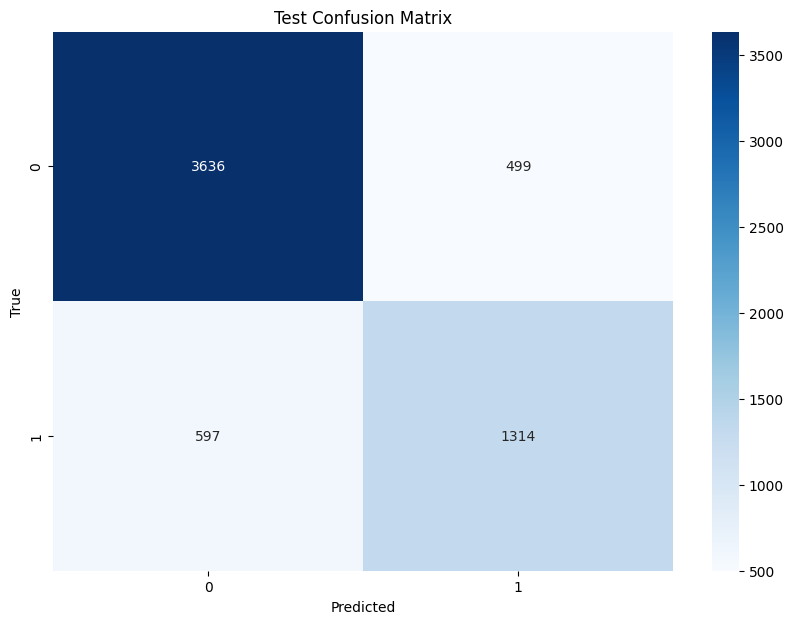

In [57]:
# Plotting Confusion matrix

from sklearn.metrics import confusion_matrix


class SuppressOutput:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

def compute_metrics(generator):
    y_true = []
    y_pred = []
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        y_true.extend(y_batch)
        with SuppressOutput():
            preds = model.predict(X_batch)
        y_pred.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred) > 0.5

    return y_true, y_pred

# Get predictions and true labels
y_true_test, y_pred_test = compute_metrics(test_generator)

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# Plot confusion matrix for test set
plot_confusion_matrix(y_true_test, y_pred_test, title='Test Confusion Matrix')

Testing precision is at 72% and the testing recall is fairly good at 68%

An additional point to note here is that we have trained the ResNet50 Model for 5 epochs due to computational contraints. The performance of the model would definitely improve further if it were trained for longer.